In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [38]:
df = pd.read_excel("Credit_Card_Data.xlsx")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,MAX_PAY,MAX_DELAY,DELAY_WT_AVG,DELAY_LOGIC,BILL_WT_AVG,PAY_WT_AVG,PAY_BILL_RATIO
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,2,2,1.166667,Ideal (Revenue Zone),2194.666667,172.250000,0.078486
1,2,120000,2,2,2,26,-1,2,0,0,...,1000,0,2000,2,2,0.666667,Low Delay,2604.583333,666.666667,0.255959
2,3,90000,2,2,2,34,0,0,0,0,...,1000,1000,5000,0,0,0.000000,No Delay,19248.583333,1631.000000,0.084734
3,4,50000,2,2,1,37,0,0,0,0,...,1100,1069,1000,0,0,0.000000,No Delay,43171.750000,1635.500000,0.037884
4,5,50000,1,2,1,57,-1,0,-1,0,...,9000,689,679,0,0,0.000000,No Delay,15197.083333,12367.583333,0.813813


In [39]:
delay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
pay_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]



In [40]:
df_fe = df.copy()

In [41]:
delay_clean = df_fe[delay_cols].clip(lower=0)
df_fe["MAX_DELAY"] = delay_clean.max(axis=1)
df_fe[delay_cols + ["MAX_DELAY"]].head()

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,MAX_DELAY
0,2,2,-1,-1,-2,-2,2
1,-1,2,0,0,0,2,2
2,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0
4,-1,0,-1,0,0,0,0


In [42]:
df_fe[bill_cols] = df_fe[bill_cols].clip(lower=0)

In [43]:
df_fe["DELAY_WT_AVG"] = (
    4 * delay_clean["PAY_0"] +
    3 * delay_clean["PAY_2"] +
    2 * delay_clean["PAY_3"] +
    1 * delay_clean["PAY_4"] +
    1 * delay_clean["PAY_5"] +
    1 * delay_clean["PAY_6"]
) / 12

In [44]:
df_fe["BILL_WT_AVG"] = (
    4 * df_fe["BILL_AMT1"] +
    3 * df_fe["BILL_AMT2"] +
    2 * df_fe["BILL_AMT3"] +
    1 * df_fe["BILL_AMT4"] +
    1 * df_fe["BILL_AMT5"] +
    1 * df_fe["BILL_AMT6"]
) / 12

In [45]:
df_fe["PAY_WT_AVG"] = (
    4 * df_fe["PAY_AMT1"] +
    3 * df_fe["PAY_AMT2"] +
    2 * df_fe["PAY_AMT3"] +
    1 * df_fe["PAY_AMT4"] +
    1 * df_fe["PAY_AMT5"] +
    1 * df_fe["PAY_AMT6"]
) / 12

In [47]:
# pay to bill ratio
df_fe["PAY_BILL_RATIO"] = np.where(
    df_fe["BILL_WT_AVG"] == 0,
    0,
    df_fe["PAY_WT_AVG"] / df_fe["BILL_WT_AVG"]
)
df_fe["PAY_BILL_RATIO"] = df_fe["PAY_BILL_RATIO"].clip(lower=0, upper=5)

In [48]:
df_fe[[
    "LIMIT_BAL",
    "MAX_DELAY",
    "DELAY_WT_AVG",
    "BILL_WT_AVG",
    "PAY_WT_AVG",
    "PAY_BILL_RATIO"
]].head()

,LIMIT_BAL,MAX_DELAY,DELAY_WT_AVG,BILL_WT_AVG,PAY_WT_AVG,PAY_BILL_RATIO
0,20000,2,1.166667,2194.666667,172.250000,0.078486
1,120000,2,0.666667,2604.583333,666.666667,0.255959
2,90000,0,0.000000,19248.583333,1631.000000,0.084734
3,50000,0,0.000000,43171.750000,1635.500000,0.037884
4,50000,0,0.000000,15197.083333,12367.583333,0.813813


In [49]:
feature_cols = [
    "LIMIT_BAL",
    "MAX_DELAY",
    "DELAY_WT_AVG",
    "BILL_WT_AVG",
    "PAY_BILL_RATIO"
]

X = df_fe[feature_cols].copy()
X.head()

,LIMIT_BAL,MAX_DELAY,DELAY_WT_AVG,BILL_WT_AVG,PAY_BILL_RATIO
0,20000,2,1.166667,2194.666667,0.078486
1,120000,2,0.666667,2604.583333,0.255959
2,90000,0,0.000000,19248.583333,0.084734
3,50000,0,0.000000,43171.750000,0.037884
4,50000,0,0.000000,15197.083333,0.813813


In [50]:
X.describe()

,LIMIT_BAL,MAX_DELAY,DELAY_WT_AVG,BILL_WT_AVG,PAY_BILL_RATIO
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,0.682200,0.308511,47440.256014,0.390995
std,129747.661567,1.073518,0.624217,66430.228148,0.591697
min,10000.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,0.000000,0.000000,4938.354167,0.042235
50%,140000.000000,0.000000,0.000000,22122.458333,0.087660
75%,240000.000000,2.000000,0.333333,60832.645833,0.635966
max,1000000.000000,8.000000,6.416667,888358.166667,5.000000


In [51]:
feature_cols = [
    "LIMIT_BAL",
    "MAX_DELAY",
    "DELAY_WT_AVG",
    "BILL_WT_AVG",
    "PAY_BILL_RATIO"
]

X = df_fe[feature_cols].copy()

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [53]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_fe["Cluster"] = kmeans.fit_predict(X_scaled)

In [58]:
import pickle

# Save trained KMeans model
with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully")

Model and scaler saved successfully


In [54]:
df_fe["Cluster"].value_counts()

Cluster
1    12018
0     7413
2     7358
3     3211
Name: count, dtype: int64

In [55]:
cluster_summary = df_fe.groupby("Cluster")[feature_cols].mean().round(2)
cluster_summary["Customer_Count"] = df_fe.groupby("Cluster").size()

cluster_summary

,LIMIT_BAL,MAX_DELAY,DELAY_WT_AVG,BILL_WT_AVG,PAY_BILL_RATIO,Customer_Count
Cluster,,,,,,
0,272399.84,0.29,0.08,9282.84,1.14,7413
1,112693.46,0.05,0.02,36200.25,0.17,12018
2,88922.53,2.27,1.10,40220.59,0.14,7358
3,310366.76,0.30,0.11,194143.98,0.07,3211


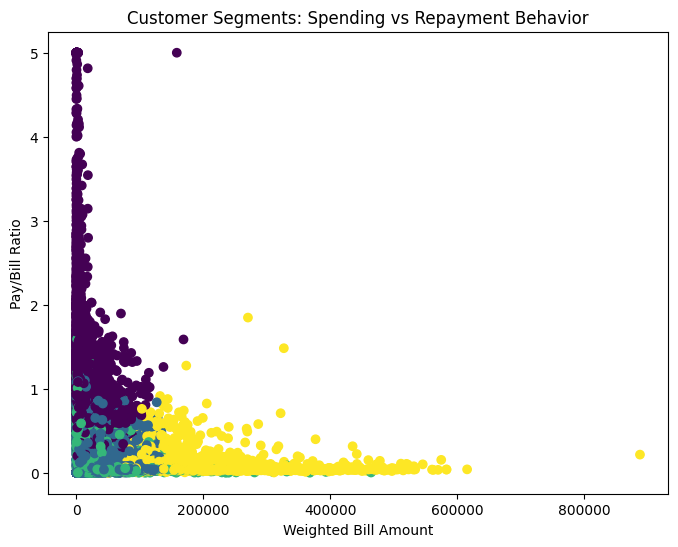

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_fe["BILL_WT_AVG"],
    df_fe["PAY_BILL_RATIO"],
    c=df_fe["Cluster"]
)

plt.xlabel("Weighted Bill Amount")
plt.ylabel("Pay/Bill Ratio")
plt.title("Customer Segments: Spending vs Repayment Behavior")

plt.show()

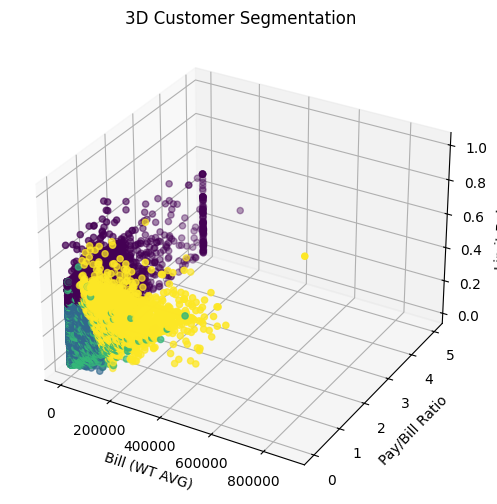

In [57]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_fe["BILL_WT_AVG"],
    df_fe["PAY_BILL_RATIO"],
    df_fe["LIMIT_BAL"],
    c=df_fe["Cluster"]
)

ax.set_xlabel("Bill (WT AVG)")
ax.set_ylabel("Pay/Bill Ratio")
ax.set_zlabel("Limit Balance")

plt.title("3D Customer Segmentation")

plt.show()

In [59]:
import os
print(os.listdir())

['app.py', 'clustering.ipynb', 'Credit_Card_Data.xlsx', 'kmeans_model.pkl', 'scaler.pkl', 'venv']
